In [5]:
import math
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm


In [6]:
def f_base(x1, x2):
    ans = 100*(x2 - x1**3)**2 + x2**2 + x1**2
    return ans

def g_base(x1, x2):
    dx1 = 2*x1 + 600*x1**5 - 600*x2*x1**2
    dx2 = 202*x2 - 200*x1**3
    return (dx1, dx2)

def H_base(x1, x2):
    x1x1 = 2 + 3000*x1**4 - 1200*x2*x1
    x1x2 = -600*x1**2
    x2x1 = -600*x1**2
    x2x2 = 202
    return [[x1x1, x1x2], [x2x1, x2x2]]

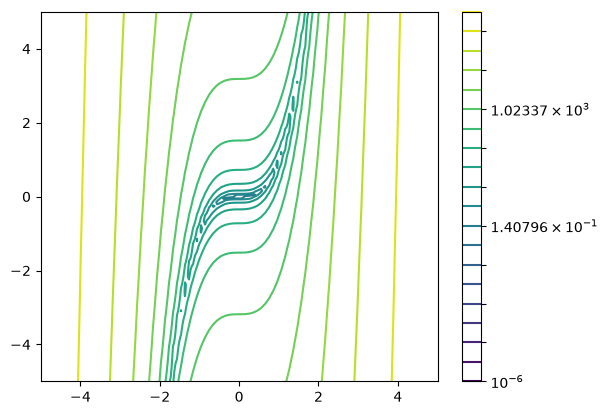

In [7]:

x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = f_base(X, Y)

Z_log = Z - Z.min() + 1e-6

levels = np.logspace(np.log10(Z_log.min()), np.log10(Z_log.max()), 20)

plt.contour(X, Y, Z_log, levels=levels, norm=LogNorm())
plt.colorbar()
plt.show()

In [ ]:
# Метод Ньютона
def method_1(eps, x, y):
    iter_c = 0
    f_call_c = 0
    
    def f(x1, x2):
        nonlocal f_call_c
        f_call_c += 1
        return f_base(x1, x2)

    def d(x1, x2):
        nonlocal f_call_c
        f_call_c += 1
        return g_base(x1, x2)

    def H(x1, x2):
        nonlocal f_call_c
        f_call_c += 1
        return H_base(x1, x2)

    x1, x2 = x, y
    run = [(x1, x2)]

    while True:
        dx = d(x1, x2)
        H = H(x1, x2)

        delta = np.linalg.solve(
            np.array(H),
            -np.array(dx)
        )

        x1_new = x1 + delta[0]
        x2_new = x2 + delta[1]

        iter_c += 1

        if math.sqrt((x1_new - x1)**2 + (x2_new - x2)**2) < eps:
            x1, x2 = x1_new, x2_new
            break

        x1 = x1_new
        x2 = x2_new
        run.append((x1, x2))
    
    return ((x1, x2), f(x1, x2), iter_c, f_call_c, run)

In [13]:
runs = []
for (x, y) in ((1, 1), (10, 0), (-5, -3)):
    for eps in (1e-2, 1e-4, 1e-6): 
        ((x_m, y_m), f, iter_c, f_call_c, run) = method_1(eps, x, y)
        print(eps, iter_c, f_call_c, (x_m, y_m), f)

        if eps == 1e-6:
            runs.append(run)
    print()


0.01 8 17 (np.float64(2.7311660894565985e-14), np.float64(-4.4202414352465663e-17)) 7.461241600166582e-28
0.0001 8 17 (np.float64(2.7311660894565985e-14), np.float64(-4.4202414352465663e-17)) 7.461241600166582e-28
1e-06 9 19 (np.float64(0.0), np.float64(0.0)) 0.0

0.01 29 59 (np.float64(8.897832686326906e-07), np.float64(-1.057945412698269e-09)) 7.918273092369452e-13
0.0001 30 61 (np.float64(5.026081750770205e-19), np.float64(-1.3949586257803447e-18)) 1.96789481309192e-34
1e-06 30 61 (np.float64(5.026081750770205e-19), np.float64(-1.3949586257803447e-18)) 1.96789481309192e-34

0.01 23 47 (np.float64(-6.90074813761328e-07), np.float64(8.205779901057642e-10)) 4.76271256759808e-13
0.0001 24 49 (np.float64(-2.344163681526276e-19), np.float64(6.507245831268376e-19)) 4.282264182530312e-35
1e-06 24 49 (np.float64(-2.344163681526276e-19), np.float64(6.507245831268376e-19)) 4.282264182530312e-35



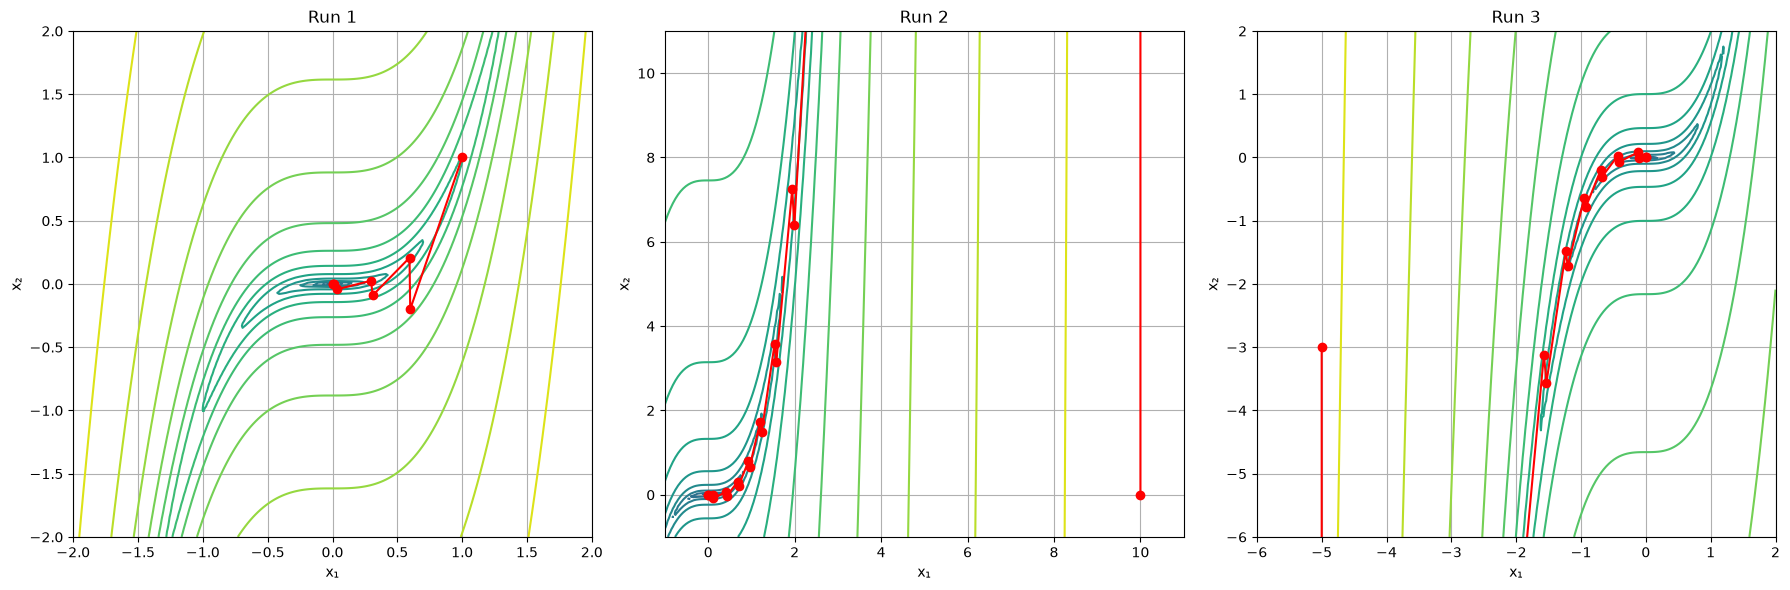

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

ranges = [
    (-2, 2, -2, 2),
    (-1, 11, -1, 11),
    (-6, 2, -6, 2)
]

for i, (ax, run, (x_min, x_max, y_min, y_max)) in enumerate(
    zip(axes, runs, ranges)
):
    # Grid for this subplot
    x = np.linspace(x_min, x_max, 200)
    y = np.linspace(y_min, y_max, 200)
    X, Y = np.meshgrid(x, y)

    Z = f_base(X, Y)

    # Shift because log scale requires positive values
    Z_log = Z - Z.min() + 1e-6

    levels = np.logspace(
        np.log10(Z_log.min()),
        np.log10(Z_log.max()),
        20
    )

    # Contour plot
    ax.contour(
        X, Y, Z_log,
        levels=levels,
        norm=LogNorm()
    )

    # Trajectory
    x_path = [point[0] for point in run]
    y_path = [point[1] for point in run]

    ax.plot(
        x_path,
        y_path,
        marker='o',
        color='red'
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    ax.set_xlabel("x₁")
    ax.set_ylabel("x₂")
    ax.set_title(f"Run {i + 1}")
    ax.grid(True)

plt.tight_layout()
plt.show()